<div style="background:linear-gradient(135deg,#42275a 0%,#734b6d 100%);padding:32px 34px;border-radius:16px;
            box-shadow:0 8px 24px rgba(0,0,0,0.18);font-family:'Segoe UI',Roboto,sans-serif;">
  <h1 style="margin:0;color:#ffffff;font-size:34px;letter-spacing:-0.5px;">🗺️&nbsp; Advanced Techniques: A Roadmap</h1>
  <p style="margin:12px 0 0;color:#eaf6ff;font-size:17px;line-height:1.5;max-width:760px;">A guided map of everything beyond a basic forward solve — transfer learning, distributed training, inverse problems, multi-scale curricula, and uncertainty quantification — with a quick check that all the machinery is importable and ready.</p>
</div>

<div><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">level</span><span style="background:#1a73e8;color:#fff;padding:4px 8px;">overview</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">topic</span><span style="background:#7b3fe4;color:#fff;padding:4px 8px;">index · capabilities</span></span><span style="display:inline-block;margin:4px 6px 0 0;border-radius:6px;overflow:hidden;font-family:'Segoe UI',sans-serif;font-size:12px;"><span style="background:#3b3b3b;color:#fff;padding:4px 8px;">runtime</span><span style="background:#1e9e54;color:#fff;padding:4px 8px;">seconds · CPU</span></span></div>

The `pinnlab` library goes well past solving a single PDE. This notebook is your **table of contents
for the advanced track**: what each capability is for, when to reach for it, and which notebook
covers it in depth.

<div style="background:#f6f8fa;border:1px solid #e1e4e8;border-radius:10px;padding:18px 24px;
            font-family:'Segoe UI',sans-serif;">
  <b style="font-size:15px;">📑 Table of Contents</b>
  <ol style="margin:10px 0 0;padding-left:20px;font-size:14px;line-height:1.6;">
  <li style="margin:3px 0;"><a href="#setup" style="color:#1a73e8;text-decoration:none;">1 · Setup & Availability Check</a></li>
  <li style="margin:3px 0;"><a href="#map" style="color:#1a73e8;text-decoration:none;">2 · The Capability Map</a></li>
  <li style="margin:3px 0;"><a href="#demo" style="color:#1a73e8;text-decoration:none;">3 · A 60-Second Taste</a></li>
  <li style="margin:3px 0;"><a href="#next" style="color:#1a73e8;text-decoration:none;">4 · Where to Dive In</a></li>
  </ol>
</div>

<a id="setup"></a>

## 1 · Setup & Availability Check

Confirm the advanced subsystems import cleanly in your environment.

In [1]:
# --- Environment setup -------------------------------------------------------
import warnings, logging, os
warnings.filterwarnings("ignore")
logging.getLogger("pinnlab").setLevel(logging.ERROR)          # quiet library logs

# Disable tqdm progress bars for clean, static notebook output
from functools import partialmethod
import tqdm
tqdm.tqdm.__init__ = partialmethod(tqdm.tqdm.__init__, disable=True)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

# A clean, consistent "Kaggle" plotting theme ---------------------------------
plt.rcParams.update({
    "figure.figsize":   (9, 5),
    "figure.dpi":       110,
    "savefig.dpi":      110,
    "font.size":        11,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.titleweight": "bold",
    "axes.labelsize":   11,
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#e6e6e6",
    "grid.linewidth":   0.8,
    "axes.axisbelow":   True,
    "legend.frameon":   True,
    "legend.framealpha":0.9,
})
ACCENT, ACCENT2, ACCENT3 = "#1a73e8", "#d6336c", "#1e9e54"

# Reproducibility -------------------------------------------------------------
SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

import pinnlab
print(f"pinnlab      : {pinnlab.__version__}")
print(f"PyTorch      : {torch.__version__}")
print(f"Compute      : {DEVICE.upper()}")

pinnlab      : 0.5.0
PyTorch      : 2.11.0+cpu
Compute      : CPU


In [2]:
import importlib
modules = {
    "Transfer learning": "pinnlab.transfer",
    "Distributed":       "pinnlab.distributed",
    "Uncertainty":       "pinnlab.uncertainty",
    "Active sampling":   "pinnlab.sampling",
    "Training utils":    "pinnlab.training",
}
for name, mod in modules.items():
    try:
        importlib.import_module(mod)
        print(f"  ✓ {name:18s} ({mod})")
    except Exception as e:                       # pragma: no cover
        print(f"  ✗ {name:18s} -> {e!r}")

  ✓ Transfer learning  (pinnlab.transfer)
  ✓ Distributed        (pinnlab.distributed)
  ✓ Uncertainty        (pinnlab.uncertainty)
  ✓ Active sampling    (pinnlab.sampling)
  ✓ Training utils     (pinnlab.training)


<a id="map"></a>

## 2 · The Capability Map

| Capability | What it does | When to use it | Deep-dive notebook |
|---|---|---|---|
| **Distributed training** | Spread collocation work across devices | Large domains, long schedules | [`02_distributed_training`](02_distributed_training.ipynb) |
| **Inverse problems** | Recover unknown PDE parameters from data | You have measurements, not coefficients | [`03_inverse_problems`](03_inverse_problems.ipynb) |
| **Multi-scale / curriculum** | Coarse→fine progressive training | Stiff PDEs, sharp fronts | [`04_multi_scale_training`](04_multi_scale_training.ipynb) |
| **Uncertainty quantification** | Error bars via ensembles / Bayes | Risk-aware predictions | [`05_uncertainty_quantification`](05_uncertainty_quantification.ipynb) |
| **Transfer learning** | Reuse a pre-trained network on a new task | Families of related PDEs | [`benchmarks/06_transfer_learning`](../benchmarks/06_transfer_learning.ipynb) |
| **Active learning** | Add collocation points where it hurts | Tight sampling budgets | [`benchmarks/01_active_learning_comparison`](../benchmarks/01_active_learning_comparison.ipynb) |

<div style="background:#fdeef2;border-left:5px solid #d6336c;border-radius:8px;
            padding:14px 18px;margin:6px 0;font-family:'Segoe UI',sans-serif;font-size:14px;line-height:1.6;">
  <b>🔑 Key Idea.</b> These compose. A realistic large run might use a multi-scale curriculum <i>and</i> active sampling <i>and</i> distributed training together.
</div>

<a id="demo"></a>

## 3 · A 60-Second Taste

A quick base solve, then a one-liner that wraps it for transfer and confirms the distributed trainer is ready — the threads picked up across the deep-dive notebooks.

Base model trained — loss 3.541e-01
Same model, ready to scale via: DistributedTrainer


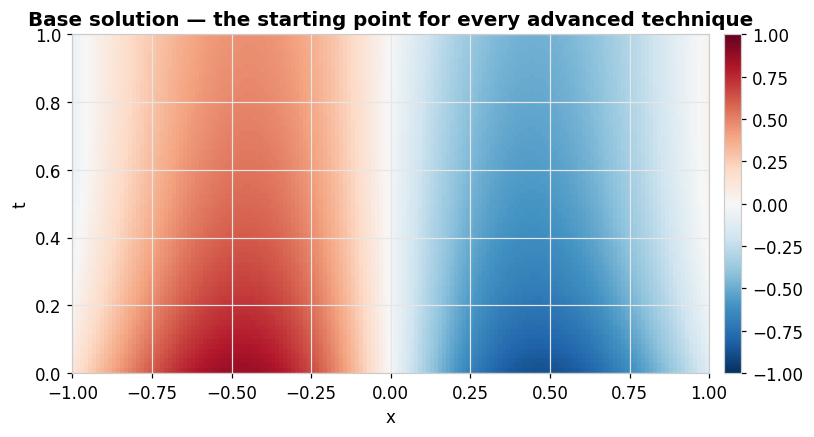

In [3]:
from pinnlab.models import MLP
from pinnlab.solvers.raissi_improved import (
    BurgersConfig, TrainConfig, ContinuousPINN, burgers_residual)
from pinnlab.distributed import DistributedTrainer

cfg = BurgersConfig()
pinn = ContinuousPINN(MLP(2, 4, 32, 1), DEVICE, burgers_residual, cfg)
hist = pinn.train(TrainConfig(n_u0=100, n_bc=60, n_f=800, adam_steps=600,
                              lbfgs_max_iter=0, seed=SEED, track_losses=True),
                  weights=(10.0, 1.0, 1.0))
print(f"Base model trained — loss {hist['total'][-1]:.3e}")

trainer = DistributedTrainer(pinn, strategy="data_parallel", devices="auto")
print("Same model, ready to scale via:", type(trainer).__name__)

nt, nx = 70, 160
TT, XX = np.meshgrid(np.linspace(cfg.tmin, cfg.tmax, nt, dtype=np.float32),
                     np.linspace(cfg.xmin, cfg.xmax, nx, dtype=np.float32), indexing="ij")
U = pinn.predict(TT, XX)
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(U, extent=[cfg.xmin, cfg.xmax, cfg.tmin, cfg.tmax], origin="lower",
               aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set(title="Base solution — the starting point for every advanced technique",
       xlabel="x", ylabel="t"); fig.colorbar(im, ax=ax, pad=0.02); plt.show()

<a id="next"></a>

## 4 · Where to Dive In

Pick the thread that matches your problem and open its notebook from the table above. If you're new
to the advanced track, a good order is:

1. [`03_inverse_problems`](03_inverse_problems.ipynb) — the most striking PINN superpower.
2. [`05_uncertainty_quantification`](05_uncertainty_quantification.ipynb) — trustworthy predictions.
3. [`04_multi_scale_training`](04_multi_scale_training.ipynb) — make hard PDEs converge.
4. [`02_distributed_training`](02_distributed_training.ipynb) — scale it all up.

<div style="background:#0d1117;border-radius:12px;padding:22px 26px;color:#c9d1d9;
            font-family:'Segoe UI',sans-serif;font-size:13px;line-height:1.6;">
  <b style="color:#fff;font-size:15px;">Thanks for reading! 🙌</b><br>
  This notebook is part of the <code>pinnlab</code> example gallery. Explore the companion notebooks in
  <code>notebooks/basic</code>, <code>notebooks/advanced</code>, and <code>notebooks/benchmarks</code>
  for more physics-informed deep-learning recipes.
</div>